In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('ML_Final_Sheet.csv')

In [3]:
display(df.head())

,formula,band_gap,rA,rB,rX,chi_A,chi_B,chi_X,EA_A,EA_B,EA_X,tolerance_factor,octahedral_factor,a,b,c,volume,density
0,AcAlO3,4.1024,1.26,0.6750,1.26,1.1,1.61,3.44,0.35,0.432835,1.461113,0.921022,0.535714,3.858634,3.858634,3.858634,57.451413,8.728230
1,AcBO3,0.8071,1.26,0.4100,1.26,1.1,2.04,3.44,0.35,0.279723,1.461113,1.067173,0.325397,3.721668,3.721668,3.721668,51.548126,9.206879
2,AcCrO3,2.0031,1.26,0.9400,1.26,1.1,1.66,3.44,0.35,0.675928,1.461113,0.810081,0.746032,3.944287,3.944302,3.944272,61.362845,8.848788
3,AcCuO3,0.0000,1.26,0.8200,1.26,1.1,1.90,3.44,0.35,1.235784,1.461113,0.856816,0.650794,3.913331,3.913331,3.913331,59.929387,9.380471
4,AcFeO3,0.9888,1.26,0.8525,1.26,1.1,1.83,3.44,0.35,0.153236,1.461113,0.843635,0.676587,3.953570,3.953568,3.953585,61.797311,8.889999


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4804 entries, 0 to 4803
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   formula            4804 non-null   object 
 1   band_gap           4804 non-null   float64
 2   rA                 4804 non-null   float64
 3   rB                 4804 non-null   float64
 4   rX                 4804 non-null   float64
 5   chi_A              4804 non-null   float64
 6   chi_B              4804 non-null   float64
 7   chi_X              4804 non-null   float64
 8   EA_A               4804 non-null   float64
 9   EA_B               4804 non-null   float64
 10  EA_X               4804 non-null   float64
 11  tolerance_factor   4804 non-null   float64
 12  octahedral_factor  4804 non-null   float64
 13  a                  4804 non-null   float64
 14  b                  4804 non-null   float64
 15  c                  4804 non-null   float64
 16  volume             4804 

In [5]:
print(df.isnull().sum())

formula              0
band_gap             0
rA                   0
rB                   0
rX                   0
chi_A                0
chi_B                0
chi_X                0
EA_A                 0
EA_B                 0
EA_X                 0
tolerance_factor     0
octahedral_factor    0
a                    0
b                    0
c                    0
volume               0
density              0
dtype: int64


In [6]:
# Check how many unique formulas vs total rows
total_rows = len(df)
unique_formulas = df['formula'].nunique()

print(f"Total entries in dataset: {total_rows}")
print(f"Unique chemical formulas: {unique_formulas}")
print(f"Average structural phases per formula: {total_rows/unique_formulas:.2f}")

Total entries in dataset: 4804
Unique chemical formulas: 2722
Average structural phases per formula: 1.76


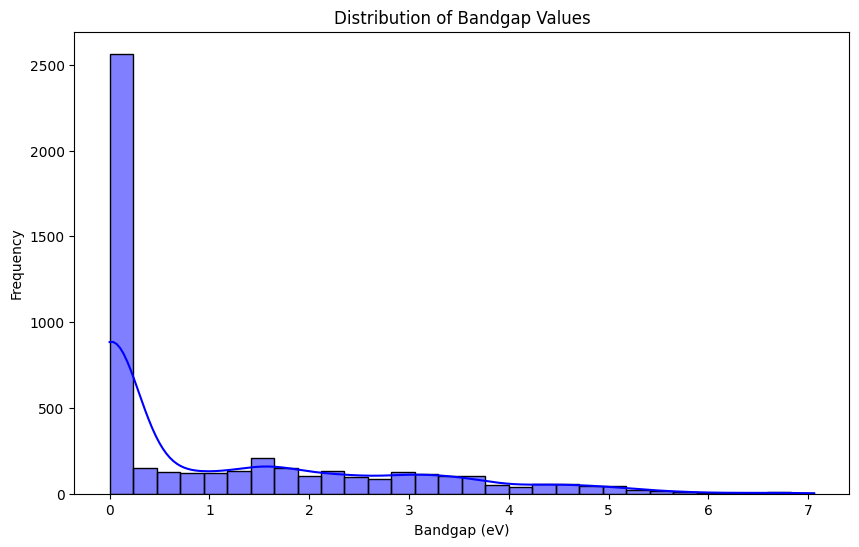

In [7]:
# Visualizing the distribution of the target variable (Bandgap)
plt.figure(figsize=(10, 6))
sns.histplot(df['band_gap'], kde=True, color='blue', bins=30)
plt.title('Distribution of Bandgap Values')
plt.xlabel('Bandgap (eV)')
plt.ylabel('Frequency')
plt.show()

In [8]:
# Count materials with 0 bandgap
zero_gap_count = len(df[df['band_gap'] == 0])
total_materials = len(df)
percentage_zero = (zero_gap_count / total_materials) * 100

print(f"--- Zero-Gap Analysis ---")
print(f"Total materials: {total_materials}")
print(f"Materials with 0 eV bandgap: {zero_gap_count}")
print(f"Percentage of metallic materials: {percentage_zero:.2f}%")

# If you want to see which chemical types have 0 gap
if zero_gap_count > 0:
    print("\nSample of 0 eV materials:")
    display(df[df['band_gap'] == 0].head())

--- Zero-Gap Analysis ---
Total materials: 4804
Materials with 0 eV bandgap: 2385
Percentage of metallic materials: 49.65%

Sample of 0 eV materials:


,formula,band_gap,rA,rB,rX,chi_A,chi_B,chi_X,EA_A,EA_B,EA_X,tolerance_factor,octahedral_factor,a,b,c,volume,density
3,AcCuO3,0.0,1.26,0.82000,1.26,1.1,1.90,3.44,0.35,1.235784,1.461113,0.856816,0.650794,3.913331,3.913331,3.913331,59.929387,9.380471
6,AcMgO3,0.0,1.26,0.86000,1.26,1.1,1.31,3.44,0.35,-0.420000,1.461113,0.840650,0.682540,4.016262,4.016262,4.016262,64.783754,7.671748
7,AcMnO3,0.0,1.26,0.87750,1.26,1.1,1.55,3.44,0.35,-0.520000,1.461113,0.833768,0.696429,3.963022,3.963022,3.963022,62.241399,8.802373
8,AcNiO3,0.0,1.26,0.74000,1.26,1.1,1.91,3.44,0.35,1.157161,1.461113,0.891089,0.587302,3.878840,3.878836,3.878812,58.358218,9.494943
9,AcPdO3,0.0,1.26,0.84625,1.26,1.1,2.20,3.44,0.35,0.562141,1.461113,0.846138,0.671627,4.055208,4.055207,4.055206,66.686674,9.497547


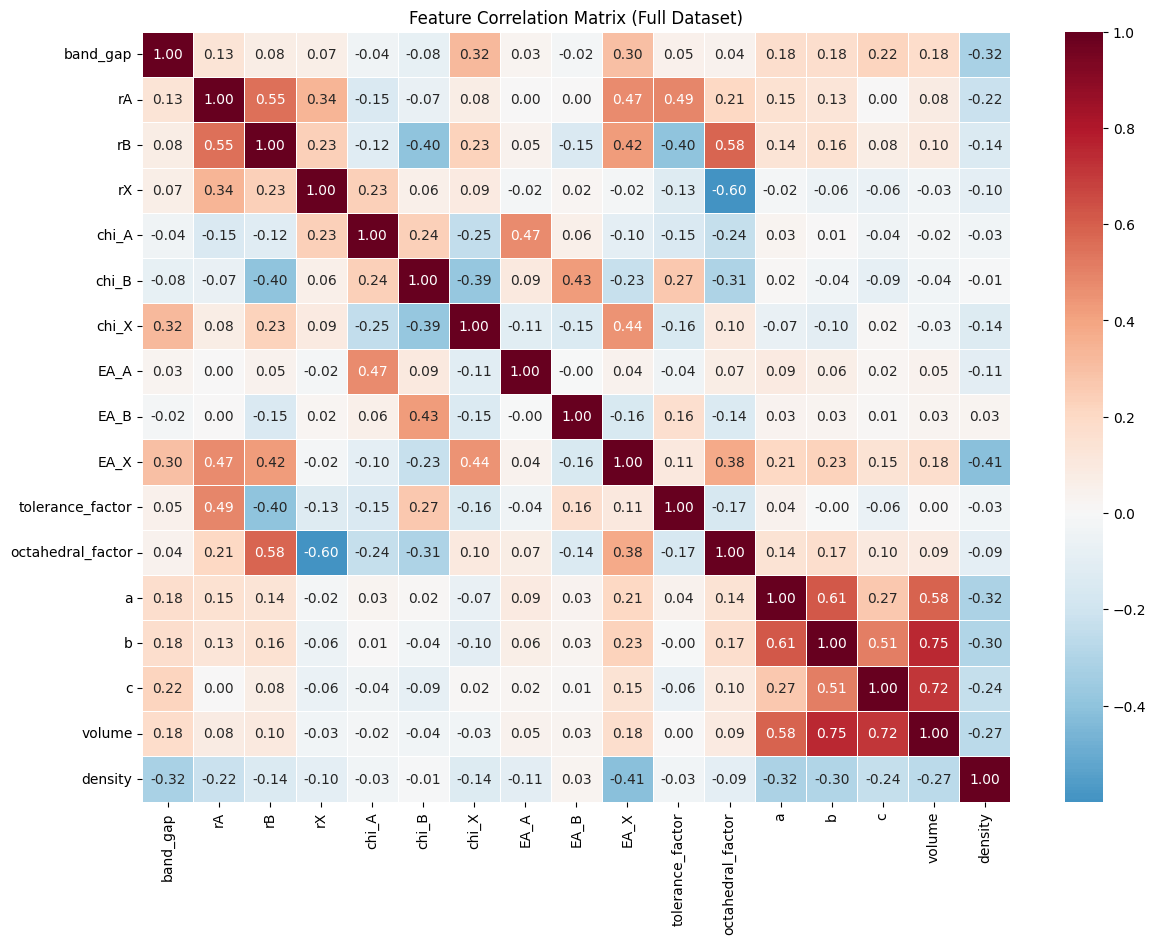

--- Features most correlated with Bandgap ---
band_gap             1.000000
chi_X                0.320517
EA_X                 0.300203
c                    0.222849
volume               0.182594
b                    0.180908
a                    0.176296
rA                   0.134862
rB                   0.080232
rX                   0.068680
tolerance_factor     0.051257
octahedral_factor    0.043777
EA_A                 0.029244
EA_B                -0.023408
chi_A               -0.040031
chi_B               -0.081539
density             -0.320744
Name: band_gap, dtype: float64


In [9]:
# 1. Prepare data for correlation (drop text columns)
numeric_df = df.drop(columns=['formula'])

# 2. Compute Correlation Matrix
corr_matrix = numeric_df.corr()

# 3. Plot the Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix (Full Dataset)')
plt.show()

# 4. Target Analysis: What correlates most with the Bandgap?
print("--- Features most correlated with Bandgap ---")
print(corr_matrix['band_gap'].sort_values(ascending=False))

In [10]:
# Create a subset of ONLY semiconductors (band_gap > 0)
semiconductors_df = df[df['band_gap'] > 0]

# Calculate correlation for this subset
semi_corr = semiconductors_df.drop(columns=['formula']).corr()

print("--- Correlation with Bandgap (SEMICONDUCTORS ONLY) ---")
print(semi_corr['band_gap'].sort_values(ascending=False))

--- Correlation with Bandgap (SEMICONDUCTORS ONLY) ---
band_gap             1.000000
chi_X                0.352916
tolerance_factor     0.149438
EA_X                 0.139170
octahedral_factor    0.062558
rA                   0.025252
c                    0.022647
volume              -0.016832
EA_B                -0.045734
a                   -0.047175
EA_A                -0.056666
b                   -0.064128
rB                  -0.081081
chi_B               -0.097180
rX                  -0.106822
density             -0.125163
chi_A               -0.175954
Name: band_gap, dtype: float64


In [11]:
print("Hello, World!")

Hello, World!


In [12]:
print("Hello, World!fesd")

Hello, World!fesd
